In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
recovered = pd.read_csv('recovered.csv')
confirmed = pd.read_csv('Confirm.csv')
deaths = pd.read_csv('death.csv')

In [3]:
# melt concept is used to convert wide data -> long data so time series data becomes possible

recovered_long =  recovered.melt(
    id_vars=['Province/State','Country/Region','Lat','Long'],
    var_name='Date',
    value_name='recovered'
)

In [4]:
# melt concept is used to convert wide data -> long data so time series data becomes possible

confirmed_long = confirmed.melt(
    id_vars = ['Province/State','Country/Region','Lat','Long'],
    var_name='Date',
    value_name='Confirmed'
)

In [5]:
# melt concept is used to convert wide data -> long data so time series data becomes possible

deaths_long = deaths.melt(
    id_vars = ['Province/State','Country/Region','Lat','Long'],
    var_name = 'Date',
    value_name='Death'
)

In [6]:
df = confirmed_long.merge(
    deaths_long[['Country/Region','Date','Death']],
    on=['Country/Region','Date']
)

df = df.merge(
    recovered_long[['Country/Region','Date','recovered']],
    on=['Country/Region','Date']
)



In [7]:
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Death,recovered
0,NaN,Afghanistan,33.93911,67.709953,1/22/20,0,0,0
1,NaN,Albania,41.15330,20.168300,1/22/20,0,0,0
2,NaN,Algeria,28.03390,1.659600,1/22/20,0,0,0
3,NaN,Andorra,42.50630,1.521800,1/22/20,0,0,0
4,NaN,Angola,-11.20270,17.873900,1/22/20,0,0,0


In [8]:
df.tail()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Death,recovered
9672155,NaN,West Bank and Gaza,31.952200,35.233200,9/21/20,36151,265,24428
9672156,NaN,Western Sahara,24.215500,-12.885800,9/21/20,10,1,8
9672157,NaN,Yemen,15.552727,48.516388,9/21/20,2028,586,1235
9672158,NaN,Zambia,-13.133897,27.849332,9/21/20,14175,331,13629
9672159,NaN,Zimbabwe,-19.015438,29.154857,9/21/20,7683,225,5924


In [9]:
#converting the date column to datetime 
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%y')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9672160 entries, 0 to 9672159
Data columns (total 8 columns):
 #   Column          Dtype         
---  ------          -----         
 0   Province/State  object        
 1   Country/Region  object        
 2   Lat             float64       
 3   Long            float64       
 4   Date            datetime64[ns]
 5   Confirmed       int64         
 6   Death           int64         
 7   recovered       int64         
dtypes: datetime64[ns](1), float64(2), int64(3), object(2)
memory usage: 590.3+ MB


In [11]:
df.describe()

,Lat,Long,Date,Confirmed,Death,recovered
count,9.672160e+06,9.672160e+06,9672160,9.672160e+06,9.672160e+06,9.672160e+06
mean,3.092793e+01,1.013850e+02,2020-05-22 11:59:59.999999488,3.482570e+03,2.538357e+02,2.379278e+03
min,-5.179630e+01,-1.350000e+02,2020-01-22 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.607890e+01,1.061655e+02,2020-03-22 18:00:00,1.260000e+02,0.000000e+00,7.500000e+01
50%,3.169270e+01,1.134244e+02,2020-05-22 12:00:00,2.600000e+02,2.000000e+00,2.280000e+02
75%,3.789570e+01,1.173230e+02,2020-07-22 06:00:00,8.940000e+02,6.000000e+00,7.520000e+02
max,7.170690e+01,1.780650e+02,2020-09-21 00:00:00,6.856884e+06,1.998650e+05,4.396399e+06
std,1.314697e+01,4.225972e+01,NaN,2.868830e+04,2.337059e+03,1.629823e+04


In [12]:
df.columns

Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Death', 'recovered'],
      dtype='object')

In [13]:
print("Mean of confirmed covid is:",df[('Confirmed')].mean())

print("Median of the Recovered from covid is:",df[('recovered')].median())

print("Minimum confirmed covid is: ",df[('Confirmed')].min())

print("Maximum death due to covid is: ",df[('Death')].max())

Mean of confirmed covid is: 3482.570142553473
Median of the Recovered from covid is: 228.0
Minimum confirmed covid is:  0
Maximum death due to covid is:  199865


In [14]:
#indai_df is created as a variable definig the country as india resetting and checking the data 
india_df = df[df['Country/Region'] == 'India']
india_df = india_df.groupby('Date')[['Confirmed','Death','recovered']].sum().reset_index()
india_df

,Date,Confirmed,Death,recovered
0,2020-01-22,0,0,0
1,2020-01-23,0,0,0
2,2020-01-24,0,0,0
3,2020-01-25,0,0,0
4,2020-01-26,0,0,0
...,...,...,...,...
239,2020-09-17,5214677,84372,4112551
240,2020-09-18,5308014,85619,4208431
241,2020-09-19,5400619,86752,4303043
242,2020-09-20,5487580,87882,4396399


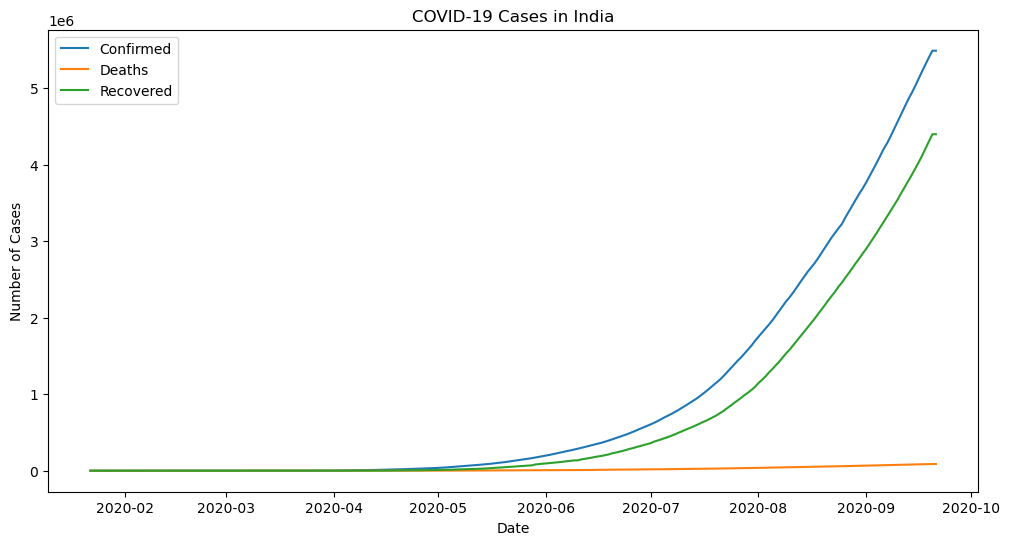

In [15]:
plt.figure(figsize=(12,6))

sns.lineplot(x='Date', y='Confirmed', data=india_df, label='Confirmed')
sns.lineplot(x='Date', y='Death', data=india_df, label='Deaths')
sns.lineplot(x='Date', y='recovered', data=india_df, label='Recovered')

plt.title("COVID-19 Cases in India")
plt.xlabel("Date")
plt.ylabel("Number of Cases")
plt.legend()
plt.show()


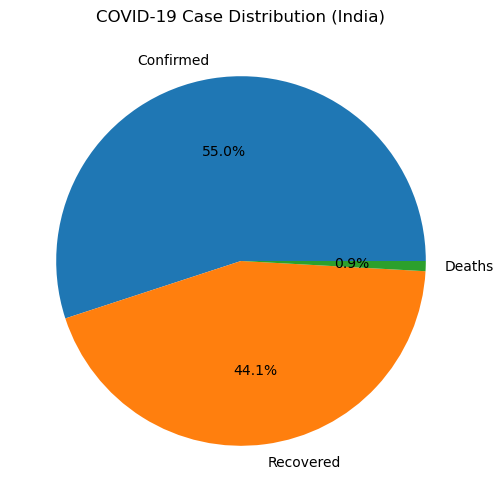

In [16]:
#iloc is a index location of the row , [-1] is last row of index.
latest = india_df.iloc[-1]

labels = ['Confirmed', 'Recovered', 'Deaths']
values = [latest['Confirmed'], latest['recovered'], latest['Death']]

plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title("COVID-19 Case Distribution (India)")
plt.show()



In [17]:
#converting date into days as date can't be understand by model.
india_df['Days'] = (india_df['Date'] - india_df['Date'].min()).dt.days
                                         

In [18]:
#classifing the data is increasing or decreasing 
#astype changing the data type of the column
india_df['NewCases'] = india_df['Confirmed'].diff().fillna(0)
india_df['Increase'] = (india_df['NewCases'] > 0).astype(int)

In [19]:
x = india_df[['Days','Death','recovered']]
y = india_df['Increase']

In [20]:
#train test split data
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [21]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [22]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(x_train,y_train)

DecisionTreeRegressor(random_state=42)

In [23]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators = 200,
    random_state = 42
)
rf.fit(x_train,y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [24]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

def evaluate_model(model,x_test,y_test):
    y_pred = model.predict(x_test)
    mae = mean_absolute_error(y_test,y_pred)
    mse = mean_squared_error(y_test,y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test,y_pred)
    return mae,mse,rmse,r2

In [25]:
lr_metrics = evaluate_model(lr, x_test, y_test)
dt_metrics = evaluate_model(dt, x_test, y_test)
rf_metrics = evaluate_model(rf, x_test, y_test)

In [26]:
model_comparison =  pd.DataFrame({
    'Model' : ['LinearRegression','Decision Tree','Random Forest'],
    'MAE' : [lr_metrics[0],dt_metrics[0],rf_metrics[0]],
    'MSE' : [lr_metrics[1],dt_metrics[1],rf_metrics[1]],
    'RMSE' : [lr_metrics[2],dt_metrics[2],rf_metrics[2]],
    'R2 Score' : [lr_metrics[3],dt_metrics[3],rf_metrics[3]]
})
model_comparison

,Model,MAE,MSE,RMSE,R2 Score
0,LinearRegression,0.141152,0.037428,0.193462,0.741546
1,Decision Tree,0.040541,0.040541,0.201347,0.720050
2,Random Forest,0.038986,0.027414,0.165571,0.810696


In [27]:
# Final model
final_model = rf

# Predict on test data
final_predictions = final_model.predict(x_test)

print(final_predictions)

[0.    0.02  1.    1.    1.    1.    1.    1.    0.75  1.    0.99  1.
 1.    1.    1.    1.    1.    0.035 1.    1.    0.    0.    1.    0.
 1.    1.    0.935 1.    1.    1.    1.    1.    0.    1.    0.    1.
 1.    1.    1.    0.535 1.    1.    1.    0.025 1.    1.    1.    0.035
 1.    1.    1.    1.    1.    1.    1.    1.    1.    0.39  1.    1.
 1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.    1.
 1.    0.   ]
